In [1]:
import re
import math
import json
import random
from collections import Counter
from typing import List, Tuple, Dict

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Configuration
WIKI_URL = "https://en.wikipedia.org/wiki/Hollow_Knight"
RANDOM_SEED = 42

def ensure_nltk():
    resources = ["punkt", "punkt_tab"]
    for r in resources:
        try:
            nltk.data.find(f"tokenizers/{r}")
        except LookupError:
            nltk.download(r)

ensure_nltk()
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [2]:
def fetch_wikipedia_article(url: str) -> str:
    headers = {"User-Agent": "Mozilla/5.0 (compatible; SGNS-Training/1.0)"}
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()

    soup = BeautifulSoup(resp.text, "html.parser")
    content_div = soup.find("div", {"id": "mw-content-text"})
    
    if content_div is None:
        raise ValueError("Could not find Wikipedia article content.")

    paragraphs = content_div.find_all(["p", "li"])
    text_blocks = [p.get_text(" ", strip=True) for p in paragraphs if p.get_text().strip()]
    
    text = "\n".join(text_blocks)
    text = re.sub(r"\[[0-9]+\]", " ", text)  # Remove citations
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_text(text: str) -> List[List[str]]:
    sentences = sent_tokenize(text)
    processed = []
    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        sent = re.sub(r"\s+", " ", sent).strip()
        if not sent: continue

        tokens = word_tokenize(sent)
        cleaned = [tok.strip("-") for tok in tokens 
                   if not tok.isdigit() and len(tok) > 1]

        if len(cleaned) >= 3:
            processed.append(cleaned)
    return processed

raw_text = fetch_wikipedia_article(WIKI_URL)
sentences = preprocess_text(raw_text)

print(f"Sentences: {len(sentences)}")
print(f"Sample Sentence: {sentences[0]}")

Sentences: 351
Sample Sentence: ['ari', 'gibson', 'william', 'pellen', 'william', 'pellen', 'david', 'kazi', 'windows', 'linux', 'macos', 'nintendo', 'switch', 'playstation', 'xbox', 'one', 'nintendo', 'switch', 'playstation', 'xbox', 'series', 'windows', 'february', 'linux', 'macos', 'april', 'nintendo', 'switch', 'june', 'playstation', 'xbox', 'one', 'september', 'nintendo', 'switch', 'playstation', 'xbox', 'series', 'february', 'hollow', 'knight', 'is', 'metroidvania', 'video', 'game', 'developed', 'and', 'published', 'by', 'australian', 'independent', 'developer', 'team', 'cherry']


In [3]:
def train_sgns(sentences: List[List[str]]) -> Word2Vec:
    model = Word2Vec(
        sentences=sentences,
        vector_size=100, # Dimensionality of embeddings
        window=10,        # Context window size
        min_count=2,     # Minimum frequency to keep a word
        workers=4,
        sg=1,            # 1 = Skip-gram
        negative=10,     # Number of negative samples
        epochs=200,      # High epochs because the dataset is small
        seed=RANDOM_SEED,
    )
    return model

print("Training Skip-gram model...")
model = train_sgns(sentences)
print(f"Vocabulary size: {len(model.wv)}")

Training Skip-gram model...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulary size: 479


In [4]:
def has_word(model: Word2Vec, word: str) -> bool:
    return word in model.wv.key_to_index

def cosine(model: Word2Vec, w1: str, w2: str) -> float:
    v1 = model.wv[w1].reshape(1, -1)
    v2 = model.wv[w2].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])

def evaluate_relatedness(model: Word2Vec, test_pairs: List[Tuple[str, str, float]]):
    covered = []
    for w1, w2, score in test_pairs:
        if has_word(model, w1) and has_word(model, w2):
            sim = cosine(model, w1, w2)
            covered.append((w1, w2, score, sim))
    return {"covered_items": covered, "total": len(test_pairs)}

def evaluate_analogies(model: Word2Vec, analogies: List[Tuple[str, str, str, str]]):
    correct, covered, details = 0, 0, []
    for a, b, c, d in analogies:
        if all(has_word(model, w) for w in [a, b, c, d]):
            covered += 1
            preds = model.wv.most_similar(positive=[b, c], negative=[a], topn=5)
            predicted_words = [w for w, _ in preds]
            hit = d in predicted_words
            if hit: correct += 1
            details.append({"analogy": f"{a}:{b}::{c}:?", "expected": d, "top_5": predicted_words})
    
    accuracy = correct / covered if covered else 0
    return {"accuracy": accuracy, "details": details}

In [5]:
# 1. Neighbor Check
probe_words = [
    "knight", "hollow", "game", "metroidvania", "cherry", "vessel", "combat",
    "hallownest", "hornet", "nail", "soul", "charm", "geo", "silksong"
]
print("=== Nearest Neighbors ===")
for word in probe_words:
    if has_word(model, word):
        neighbors = model.wv.most_similar(word, topn=5)
        print(f"\n{word}:")
        for neigh, score in neighbors:
            print(f"  {neigh:20s} {score:.4f}")
    else:
        print(f"\n{word}: [OOV]")

# 2. Relatedness Test
relatedness_test = [
    ("knight", "vessel", 0.90),
    ("team", "cherry", 0.95),
    ("metroidvania", "genre", 0.85),
    ("combat", "enemies", 0.80),
    ("hollow", "knight", 0.95),
    ("pale", "king", 0.90),
    ("nail", "weapon", 0.85),
    ("soul", "spells", 0.80),
    ("geo", "currency", 0.85),
    ("silksong", "sequel", 0.95),
    ("dirtmouth", "town", 0.75),
    ("game", "pizza", 0.01),      # Distractor
    ("knight", "tractor", 0.01),  # Distractor
]
rel_results = evaluate_relatedness(model, relatedness_test)
print("\n=== Relatedness Results ===")
for w1, w2, gold, pred in rel_results["covered_items"]:
    print(f"{w1:12s} - {w2:10s} | Expected: {gold:.2f} Pred: {pred:.4f}")

# 3. Analogy Test (a : b :: c : d -> b - a + c ≈ d)
analogy_test = [
    ("team", "cherry", "hollow", "knight"),
    ("platform", "pc", "console", "switch"),
    ("weapon", "nail", "currency", "geo"),
    ("health", "masks", "magic", "soul"),
    ("ari", "gibson", "william", "pellen"),
    ("original", "game", "sequel", "silksong"),
]
analogy_results = evaluate_analogies(model, analogy_test)
print(f"\n=== Analogy Accuracy (Top 5): {analogy_results['accuracy']:.2%} ===")
for item in analogy_results["details"]:
    print(item)

# 4. Direct Similarity Checks
print("\n=== Direct Similarity Checks ===")
check_pairs = [
    ("knight", "vessel"),
    ("team", "cherry"),
    ("metroidvania", "genre"),
    ("combat", "enemies"),
    ("hollow", "knight"),
    ("pale", "king"),
    ("nail", "weapon"),
    ("soul", "spells"),
    ("geo", "currency"),
    ("silksong", "sequel"),
    ("dirtmouth", "town"),
    ("game", "pizza"),      # Distractor
    ("knight", "tractor")   # Distractor
]
for w1, w2 in check_pairs:
    if has_word(model, w1) and has_word(model, w2):
        print(f"{w1:10s} <-> {w2:10s}: {cosine(model, w1, w2):.4f}")
    else:
        print(f"{w1:10s} <-> {w2:10s}: OOV")

# Save model
model.save("hollow_knight_sgns.model")

=== Nearest Neighbors ===

knight:
  hollow               0.7014
  website              0.4049
  guide                0.3805
  refreshed            0.3782
  silksong             0.3768

hollow:
  knight               0.7014
  website              0.4285
  refreshed            0.4248
  guide                0.4116
  now                  0.4044

game:
  academy              0.4171
  national             0.4065
  trade                0.4058
  but                  0.4031
  zelda                0.3922

metroidvania:
  independent          0.6455
  design               0.6308
  gameplay             0.6232
  developed            0.5925
  developer            0.5788

cherry:
  team                 0.7560
  chris                0.5083
  wanted               0.4945
  years                0.4944
  website              0.4854

vessel:
  abyss                0.8109
  locked               0.7521
  escape               0.7352
  within               0.6837
  managed              0.6827

combat:
  style

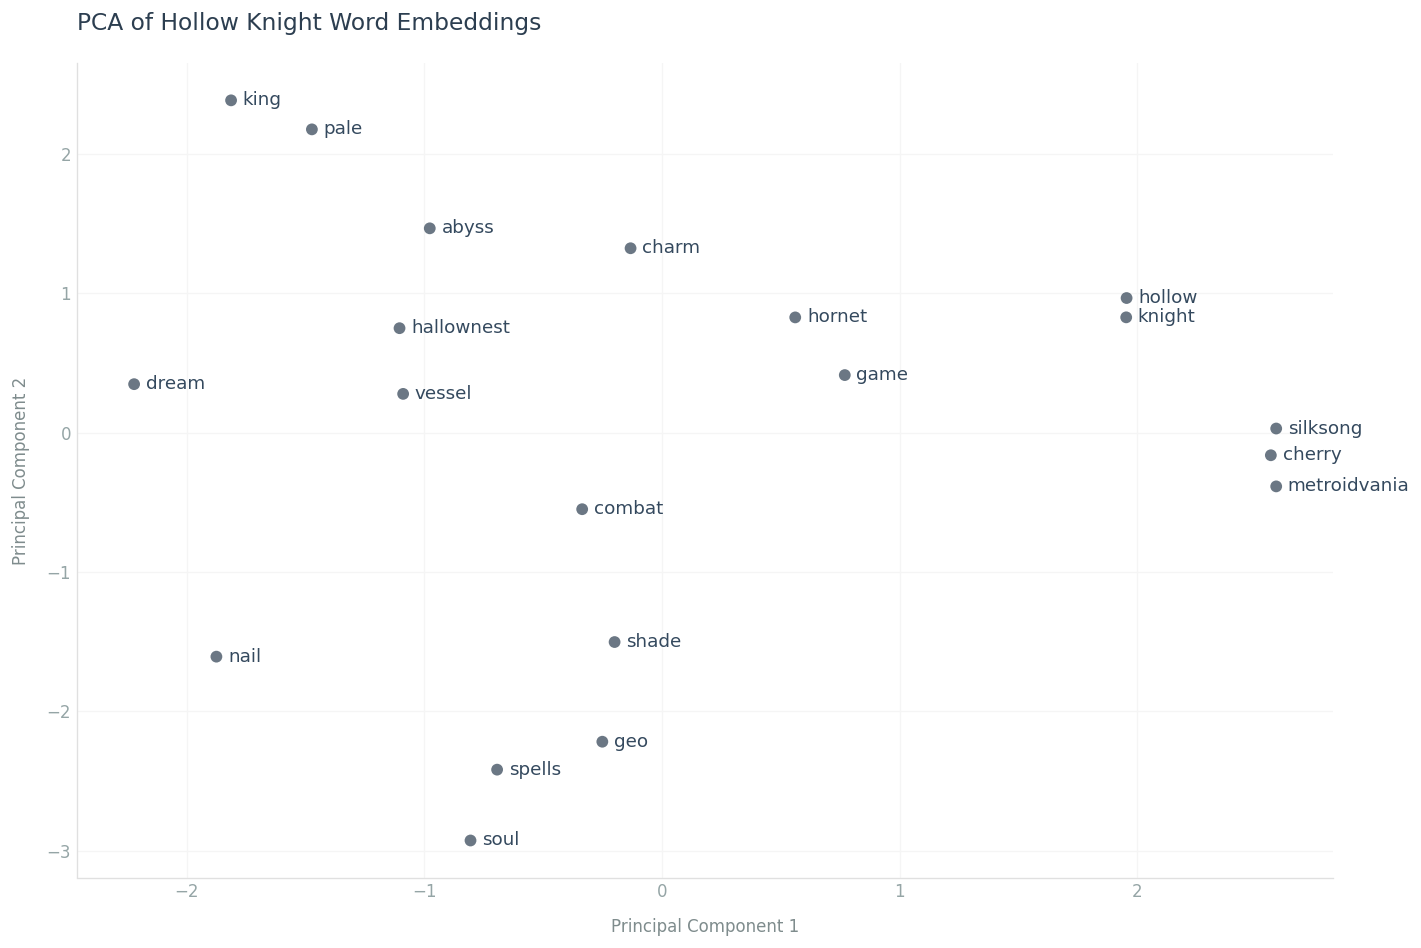

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

words_to_visualize = [
    "knight", "hollow", "game", "metroidvania", "cherry", 
    "vessel", "combat", "hallownest", "hornet", "nail", 
    "soul", "charm", "geo", "silksong", "pale", 
    "king", "spells", "shade", "abyss", "dream"
]

valid_words = [word for word in words_to_visualize if word in model.wv.key_to_index]

word_vectors = np.array([model.wv[word] for word in valid_words])

pca = PCA(n_components=2)
twodim_vectors = pca.fit_transform(word_vectors)

fig, ax = plt.subplots(figsize=(12, 8), dpi=120)
fig.patch.set_facecolor('#FFFFFF')
ax.set_facecolor('#FFFFFF')

ax.scatter(twodim_vectors[:, 0], twodim_vectors[:, 1], 
           c='#2C3E50', alpha=0.7, s=50, edgecolors='none', zorder=3)

for i, word in enumerate(valid_words):
    ax.annotate(word, 
                xy=(twodim_vectors[i, 0], twodim_vectors[i, 1]),
                xytext=(7, 0), # Shifted slightly to the right
                textcoords='offset points',
                ha='left',
                va='center',
                fontsize=11,
                color='#34495E',
                fontfamily='sans-serif',
                zorder=4)

ax.set_title("PCA of Hollow Knight Word Embeddings", 
             fontsize=14, pad=20, color='#2C3E50', loc='left')
ax.set_xlabel("Principal Component 1", fontsize=10, color='#7F8C8D', labelpad=10)
ax.set_ylabel("Principal Component 2", fontsize=10, color='#7F8C8D', labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#E0E0E0')
ax.spines['bottom'].set_color('#E0E0E0')

ax.grid(True, linestyle='-', color='#F5F5F5', zorder=0)
ax.set_axisbelow(True)

ax.tick_params(colors='#95A5A6', which='both', length=0)

plt.tight_layout()
plt.show()